## Sobre el data Set

El conjunto de datos de FIFA19 es una compilación exhaustiva de atributos de jugadores, estadísticas
y otra información relevante del videojuego. Incluye detalles sobre más de 17,000 futbolistas con 75
atributos, abarcando aspectos como edad, posición de juego, calificaciones generales, potencial y una
variedad de atributos de habilidad tanto ofensivos como defensivos. Estos atributos de habilidad incluyen,
entre otros, velocidad, dribbling, pase, disparo, defensa, y habilidades de portero.

El propósito de este análisis es identificar segmentos de jugadores dentro del conjunto de datos que compartan características similares. Al agrupar a los jugadores de esta manera, se busca descubrir un equilibrio
que, a futuro, permita crear combinaciones  óptimas de jugadores en un equipo ficticio, maximizando así
sus potenciales colaborativos y rendimiento conjunto.

In [113]:
# Librerías

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


random_seed = 333 # Semilla para reproducibilidad de resultados
np.random.seed(random_seed) # Para reproducibilidad

### Análisis exploratorio de los datos


In [114]:
# 1. Carga de datos
df = pd.read_csv('FIFA19-DS.csv', index_col=0)

In [115]:
# 2. Exploración de datos
print(df.shape)
display(df.head())

(17140, 75)


,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
ID,,,,,,,,,,,,,,,,,,,,,
158023,31,94,94,110500000,565000,2202,5,4,4,4,...,28,26,6,11,15,14,8,Left,Lean,ST
20801,33,94,94,77000000,405000,2228,5,4,5,6,...,31,23,7,11,15,14,11,Right,Normal,ST
190871,26,92,93,118500000,290000,2143,5,5,5,7,...,24,33,9,9,15,15,11,Right,Lean,AM
192985,27,91,92,102000000,355000,2281,4,5,4,8,...,58,51,15,13,5,10,13,Right,Normal,MF
183277,27,91,91,93000000,340000,2142,4,4,4,7,...,27,22,11,12,6,8,8,Right,Normal,ST


In [116]:
# Identificación de tipo y cantidad de datos faltantes
print(df.info())


<class 'pandas.core.frame.DataFrame'>
Index: 17140 entries, 158023 to 242844
Data columns (total 75 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       17140 non-null  int64  
 1   Overall                   17140 non-null  int64  
 2   Potential                 17140 non-null  int64  
 3   Value                     17140 non-null  int64  
 4   Wage                      17140 non-null  int64  
 5   Special                   17140 non-null  int64  
 6   International Reputation  17140 non-null  int64  
 7   Weak Foot                 17140 non-null  int64  
 8   Skill Moves               17140 non-null  int64  
 9   Work Rate                 17140 non-null  int64  
 10  Height                    17140 non-null  float64
 11  Weight                    17140 non-null  int64  
 12  LS                        15298 non-null  float64
 13  ST                        15298 non-null  float64
 14  RS   

In [117]:
# Columnas donde hay nulos
df.isnull().sum().sort_values(ascending=False).head(28)

RB             1842
RW             1842
CAM            1842
RAM            1842
LM             1842
LCM            1842
RCM            1842
RM             1842
LWB            1842
LDM            1842
CDM            1842
RDM            1842
RWB            1842
LB             1842
LCB            1842
CB             1842
RCB            1842
LAM            1842
CM             1842
RF             1842
LF             1842
LW             1842
RS             1842
ST             1842
LS             1842
CF             1842
LongShots         0
Positioning       0
dtype: int64

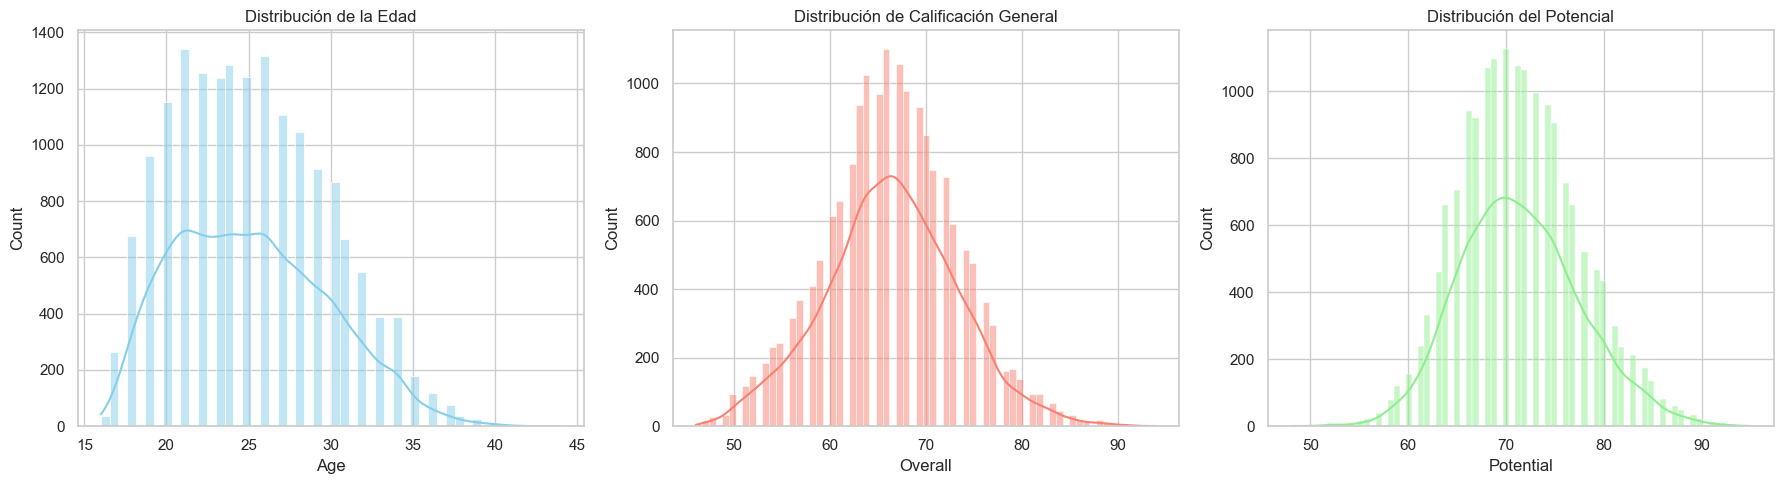

In [118]:
# Configuramos el estilo visual
sns.set(style="whitegrid")

# Creamos una figura con 3 subgráficos para comparar
plt.figure(figsize=(18, 5))

# 1. Distribución de la Edad
plt.subplot(1, 3, 1)
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribución de la Edad')

# 2. Distribución de Overall (Calificación Actual)
plt.subplot(1, 3, 2)
sns.histplot(df['Overall'], kde=True, color='salmon')
plt.title('Distribución de Calificación General')

# 3. Distribución de Potential (Calificación Futura)
plt.subplot(1, 3, 3)
sns.histplot(df['Potential'], kde=True, color='lightgreen')
plt.title('Distribución del Potencial')

plt.tight_layout()
plt.show()

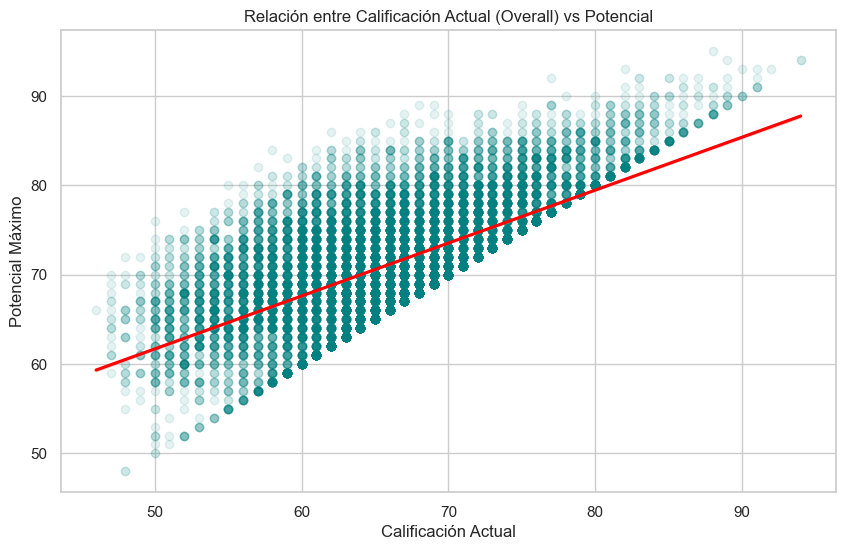

In [119]:
plt.figure(figsize=(10, 6))

# Creamos un gráfico de dispersión con una línea de tendencia
sns.regplot(data=df, x='Overall', y='Potential', 
            scatter_kws={'alpha':0.1, 'color':'teal'}, 
            line_kws={'color':'red'})

plt.title('Relación entre Calificación Actual (Overall) vs Potencial')
plt.xlabel('Calificación Actual')
plt.ylabel('Potencial Máximo')
plt.show()

In [120]:
# 1. Separar Porteros de Jugadores de Campo
# Basándonos en la columna 'Position'
df_field = df[df['Position'] != 'GK'].copy()
df_gk = df[df['Position'] == 'GK'].copy()

print(f"Jugadores de campo: {df_field.shape[0]}")
print(f"Porteros: {df_gk.shape[0]}")

# 2. Verificar nulos restantes en jugadores de campo
# Si los nulos eran los porteros, df_field debería estar casi limpio
print("\nNulos en 'Finishing' (jugadores de campo):", df_field['Finishing'].isnull().sum())

Jugadores de campo: 15298
Porteros: 1842

Nulos en 'Finishing' (jugadores de campo): 0


In [121]:
df_field.head()

,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,...,StandingTackle,SlidingTackle,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position
ID,,,,,,,,,,,,,,,,,,,,,
158023,31,94,94,110500000,565000,2202,5,4,4,4,...,28,26,6,11,15,14,8,Left,Lean,ST
20801,33,94,94,77000000,405000,2228,5,4,5,6,...,31,23,7,11,15,14,11,Right,Normal,ST
190871,26,92,93,118500000,290000,2143,5,5,5,7,...,24,33,9,9,15,15,11,Right,Lean,AM
192985,27,91,92,102000000,355000,2281,4,5,4,8,...,58,51,15,13,5,10,13,Right,Normal,MF
183277,27,91,91,93000000,340000,2142,4,4,4,7,...,27,22,11,12,6,8,8,Right,Normal,ST


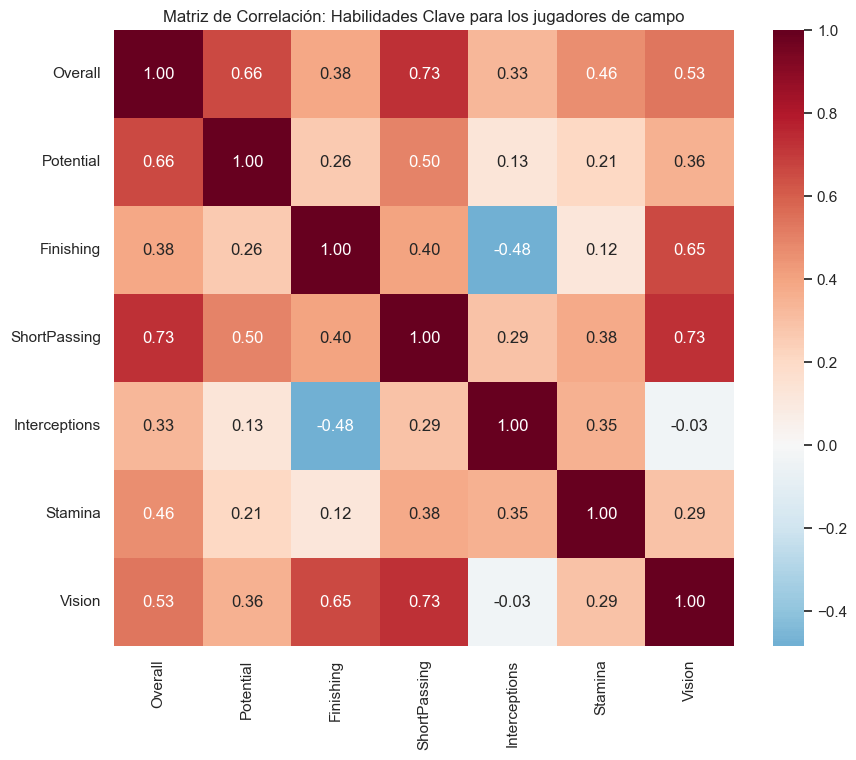

In [122]:
# Asumo que el futbol esun deporte de equipo donde hay ciertas habulidades que son más relevantes para ciertos roles. 
# Por ejemplo, 'Finishing' es crucial para delanteros, mientras que 'Interceptions' es más relevante para defensores.
#  Al analizar la correlación entre estas habilidades y el 'Overall' o 'Potential', podemos identificar qué habilidades
#  tienen un mayor impacto en la calificación general de los jugadores de campo.

# Seleccionamos un subconjunto representativo.
features_eda = [
    'Overall', 'Potential', 'Finishing', 
    'ShortPassing', 'Interceptions', 'Stamina', 'Vision'
]

# Calculamos la matriz de correlación
corr_matrix = df_field[features_eda].corr()

# Graficamos el mapa de calor (Heatmap)
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Matriz de Correlación: Habilidades Clave para los jugadores de campo')
plt.show()

In [123]:
# Comprobamos nulos en el dataset de jugadores de campo (df_field)
nulos_restantes = df_field[['Finishing', 'ShortPassing', 'Vision', 'Interceptions']].isnull().sum()

print("Nulos en el dataset de jugadores de campo:")
print(nulos_restantes)

if nulos_restantes.sum() == 0:
    print("\n✅ ¡Confirmado! Los nulos eran efectivamente los porteros. El set de campo está limpio.")
else:
    print("\n⚠️ Aún quedan nulos. Necesitamos revisar si hay registros incompletos en jugadores de campo.")

Nulos en el dataset de jugadores de campo:
Finishing        0
ShortPassing     0
Vision           0
Interceptions    0
dtype: int64

✅ ¡Confirmado! Los nulos eran efectivamente los porteros. El set de campo está limpio.


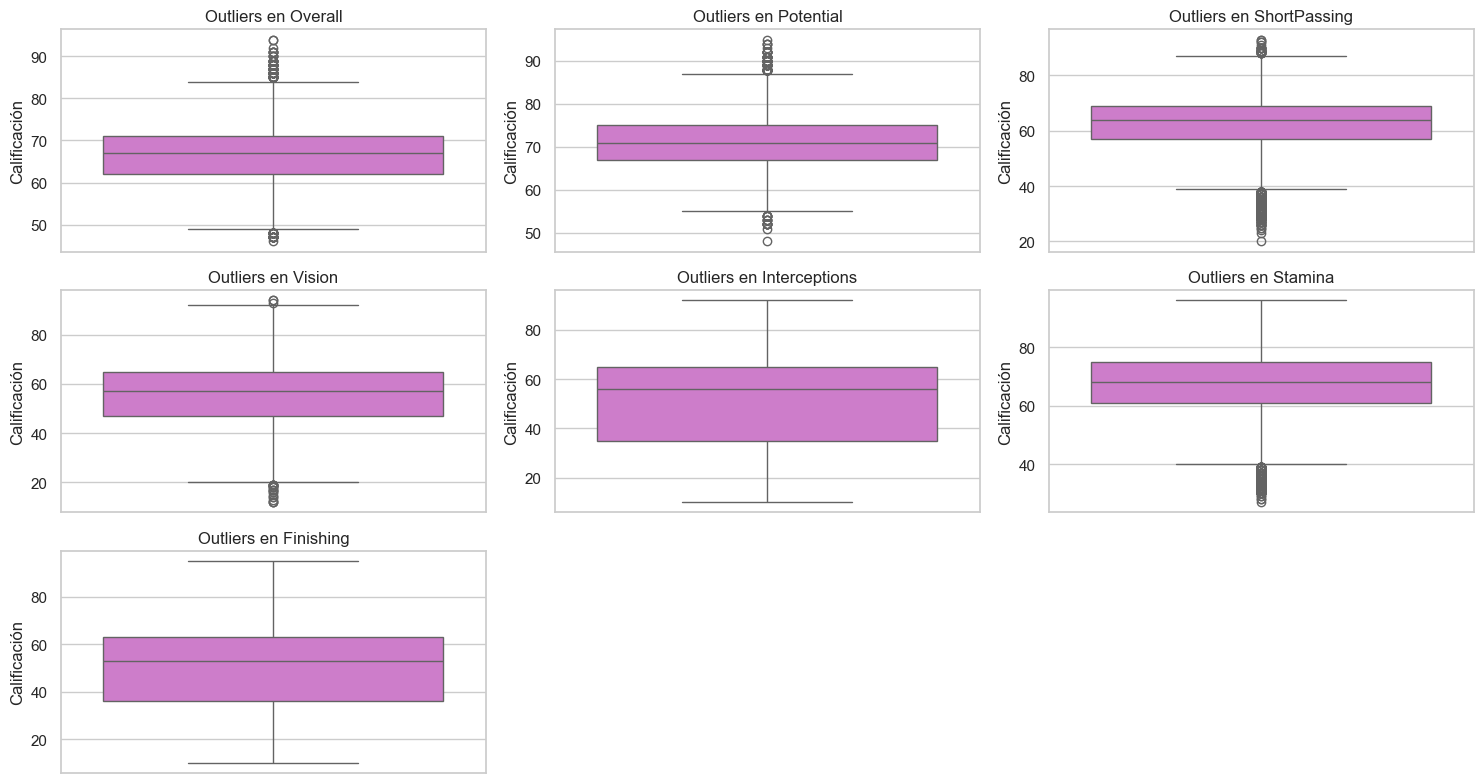

In [124]:
# Definimos las variables que hemos discutido hasta ahora
variables_analisis = ['Overall', 'Potential', 'ShortPassing',
                      'Vision', 'Interceptions', 'Stamina', 'Finishing']

plt.figure(figsize=(15, 8))

# Creamos un boxplot para cada variable
for i, col in enumerate(variables_analisis, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=df_field[col], color='orchid')
    plt.title(f'Outliers en {col}')
    plt.ylabel('Calificación')

plt.tight_layout()
plt.show()

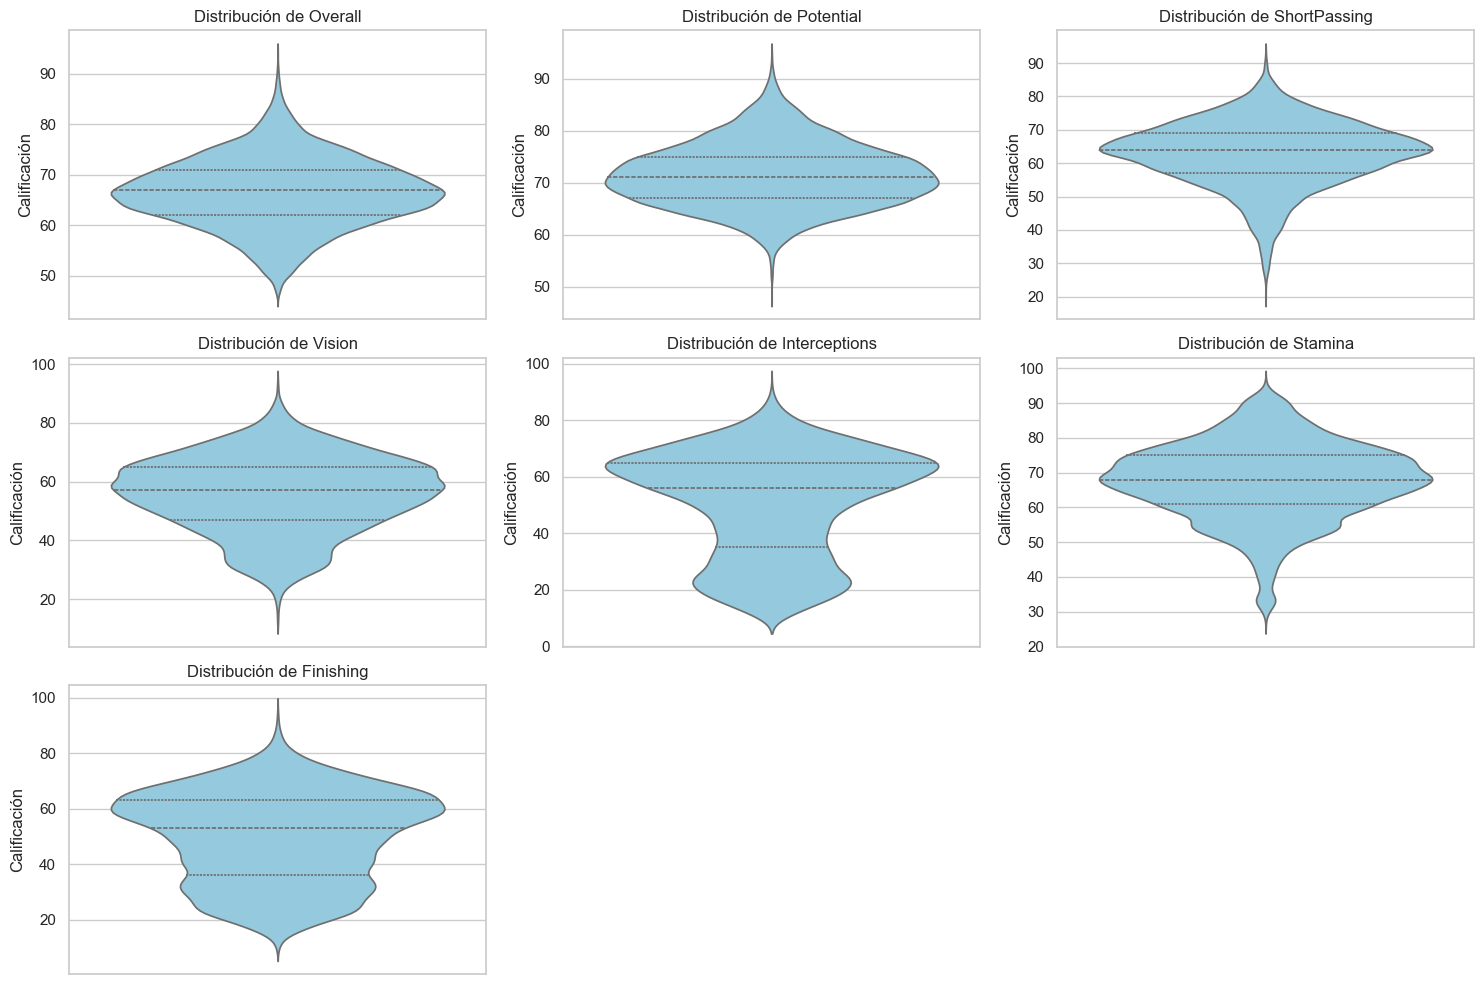

In [125]:
plt.figure(figsize=(15, 10))

# Generamos los gráficos de violín
for i, col in enumerate(variables_analisis, 1):
    plt.subplot(3, 3, i)
    sns.violinplot(y=df_field[col], color='skyblue', inner='quartile')
    plt.title(f'Distribución de {col}')
    plt.ylabel('Calificación')

plt.tight_layout()
plt.show()

In [126]:
import pandas as pd
import numpy as np

# 1. Seleccionamos las variables de interés (las que veníamos analizando)
variables_vif = ['Overall', 'Potential', 'Finishing', 'ShortPassing', 'Vision', 'Interceptions', 'Stamina']
X_vif = df_field[variables_vif]

# 2. Calculamos la matriz de correlación
corr_matrix = X_vif.corr()

# 3. Calculamos la inversa de la matriz de correlación (usando numpy)
# Nota: La diagonal de la matriz inversa representa los VIF de cada variable
vif_values = np.diag(np.linalg.inv(corr_matrix.values))

# 4. Creamos un DataFrame para visualizarlo con claridad
vif_df = pd.DataFrame({
    'Variable': variables_vif,
    'VIF': vif_values
}).sort_values(by='VIF', ascending=False)

print("Análisis de Multicolinealidad (VIF) - Método Algebraico:")
print(vif_df)

Análisis de Multicolinealidad (VIF) - Método Algebraico:
        Variable       VIF
0        Overall  3.645968
3   ShortPassing  3.559955
2      Finishing  3.441850
4         Vision  3.242279
5  Interceptions  2.662722
1      Potential  1.836893
6        Stamina  1.399447


<Figure size 1000x800 with 0 Axes>

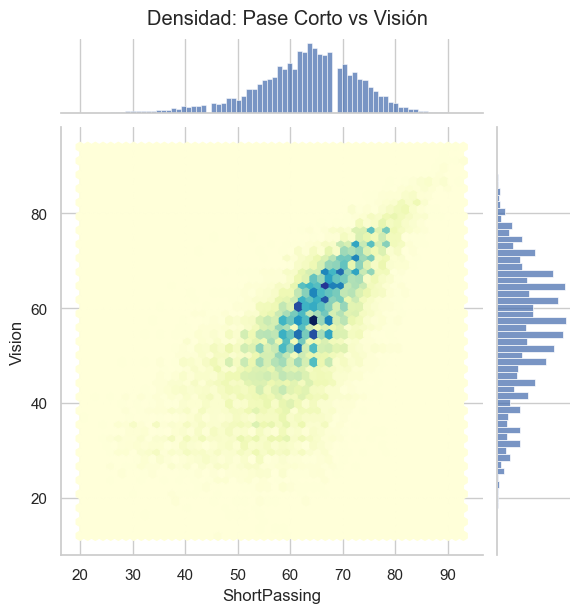

In [127]:
plt.figure(figsize=(10, 8))

# Usamos un jointplot para ver la relación y las distribuciones al mismo tiempo
sns.jointplot(data=df_field, x='ShortPassing', y='Vision', 
              kind='hex', cmap='YlGnBu')

plt.suptitle('Densidad: Pase Corto vs Visión', y=1.02)
plt.show()

Distribuciones: Son normales (bueno para el modelo).

Outliers: No hay errores, solo jugadores de élite.

Independencia (VIF): Las variables no se estorban entre sí.

Densidad: Hay una relación clara, pero con suficiente espacio para encontrar perfiles distintos.

### Escalado de datos

In [128]:
from sklearn.preprocessing import StandardScaler

# Nota: Quitamos nombres y otras columnas de texto para el entrenamiento
variables_finales = [
    'Overall', 'Potential', 'Finishing', 
    'ShortPassing', 'Vision', 'Interceptions', 'Stamina'
]

# 2. Creamos el subconjunto de datos
X = df_field[variables_finales].copy()

# 3. Inicializamos y aplicamos el escalador
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Convertimos de vuelta a DataFrame para que sea legible
X_scaled_df = pd.DataFrame(X_scaled, columns=variables_finales)

print("Datos escalados (primeras 5 filas):")
display(X_scaled_df.head())


# 5. Verificación de rigor: Media ~ 0 y Desviación Estándar = 1
print("Resumen estadístico de los datos escalados:")
display(X_scaled_df.describe().round(2).loc[['mean', 'std']])



Datos escalados (primeras 5 filas):


,Overall,Potential,Finishing,ShortPassing,Vision,Interceptions,Stamina
0,4.032873,3.677574,2.757318,2.781412,2.966525,-1.528743,0.403181
1,4.032873,3.677574,2.696098,1.858798,2.035818,-1.154956,1.834882
2,3.738624,3.513610,2.267552,2.166336,2.423613,-0.781168,1.208513
3,3.591500,3.349647,1.961449,2.986438,2.966525,0.553788,2.013845
4,3.591500,3.185683,2.083890,2.678900,2.578731,-0.514177,1.387475


Resumen estadístico de los datos escalados:


,Overall,Potential,Finishing,ShortPassing,Vision,Interceptions,Stamina
mean,0.0,0.0,0.0,0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0


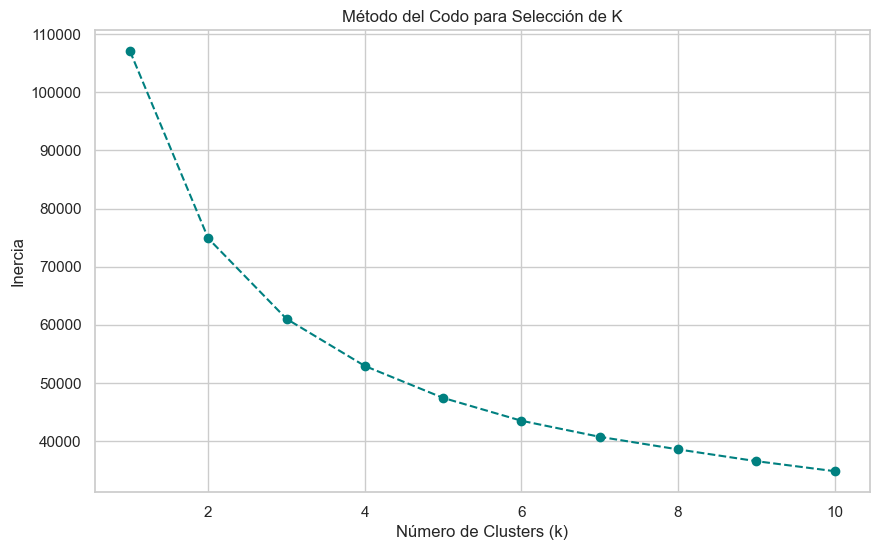

In [129]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Calculamos la inercia para diferentes valores de K
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inercia.append(kmeans.inertia_)

# 2. Graficamos los resultados
plt.figure(figsize=(10, 6))
plt.plot(rango_k, inercia, marker='o', linestyle='--', color='teal')
plt.title('Método del Codo para Selección de K')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inercia')
plt.grid(True)
plt.show()

#### El Análisis del "Codo"

De k=1 a k=3: La caída de la inercia es drástica. Esto significa que agrupar a los jugadores en 2 o 3 bloques reduce muchísimo el "error", pero los grupos serían demasiado generales (quizás solo "Buenos", "Promedio" y "Malos").

El punto de inflexión (k=4 o k=5): Si te fijas, entre 4 y 5 es donde la curva realmente empieza a cambiar de pendiente y a volverse más lineal.

Con k=4: Tendríamos grupos muy sólidos y robustos.

Con k=5: Ganamos un poco más de granularidad, lo cual es útil si queremos encontrar perfiles más específicos (como ese "especialista" que vimos en el EDA).


Dado que buscamos "combinaciones óptimas de equipo", tener 5 grupos suele ser el "punto dulce" en FIFA. Nos permite identificar perfiles como:

- Élite (Top performers).

- Defensivos puros.

- Creadores/Pasadores.

- Finalizadores (Delanteros).

- Jugadores de soporte/fondo físico.

In [130]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

resultados_metricas = []

for k in [4, 5]:
    # Entrenamos el modelo para cada K
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    
    # Calculamos métricas
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    
    resultados_metricas.append({
        'K': k,
        'Silhouette': round(sil, 4),
        'Calinski-Harabasz': round(ch, 2),
        'Davies-Bouldin': round(db, 4)
    })

# Visualizamos la comparación
df_metricas = pd.DataFrame(resultados_metricas)
display(df_metricas)

,K,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,4,0.2191,5220.42,1.3689
1,5,0.2121,4811.76,1.3241


Aunque K=5 mejora levemente el Davies-Bouldin, la caída en Calinski-Harabasz y la Silueta sugieren que el modelo de 4 grupos es el más estable. En ciencia de datos, cuando las métricas están divididas, solemos optar por la parsimonia (el modelo más simple que explique bien los datos).

Los 4 perfiles probables que encontrará el modelo:

Defensa Firme: Altos en Interceptions y Stamina.

Motor del Medio / Creativos: Altos en ShortPassing y Vision.

Finalizadores: Altos en Finishing y Potential.

Promedio / Soporte: Valores medios en todo, el grueso de la liga.

In [131]:
from sklearn.cluster import KMeans

# 1. Ajustamos el modelo final con K=4
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_field['Cluster'] = kmeans_final.fit_predict(X_scaled)

# 2. Calculamos la media de las variables originales para que tengan sentido futbolístico (0-100)
# Agregamos también el conteo de jugadores por grupo
perfil_clusters = df_field.groupby('Cluster')[variables_finales].mean()
perfil_clusters['Cantidad'] = df_field['Cluster'].value_counts()

# 3. Ordenamos por Overall para identificar rápidamente la jerarquía
print("Análisis de Perfiles por Cluster (Valores Promedio):")
df_perfiles = perfil_clusters.sort_values(by='Overall', ascending=False).round(2)
display(df_perfiles)

Análisis de Perfiles por Cluster (Valores Promedio):


,Overall,Potential,Finishing,ShortPassing,Vision,Interceptions,Stamina,Cantidad
Cluster,,,,,,,,
2,74.72,77.94,64.01,73.53,69.93,54.52,73.92,3379
1,67.25,70.69,44.39,65.52,56.66,63.23,72.92,4712
3,63.10,69.80,60.09,58.68,55.58,28.06,60.38,4213
0,61.28,68.25,28.63,52.55,38.56,58.15,61.73,2994


1. Cluster 2: "La Élite / Versátiles" (Promedio Overall: 74.72)

Identidad: Son los mejores jugadores del dataset.

Análisis: Tienen el Overall y Potential más altos. Lo más destacado es que son los más equilibrados: tienen el mejor pase (73.53) y la mejor visión (69.93), pero no descuidan la defensa (54.52 en intercepciones).

Perfil: Aquí están los "jugadores franquicia", creadores de juego y estrellas que dominan múltiples áreas.

2. Cluster 1: "El Motor y Equilibrio" (Promedio Overall: 67.25)

Identidad: Jugadores de alto despliegue físico y técnico.

Análisis: ¡Ojo aquí! Tienen las Intercepciones más altas (63.23) y una Stamina envidiable (72.92). Sin embargo, su capacidad de definición (Finishing 44.39) es limitada.

Perfil: Estos son tus Mediocampistas Defensivos (CDM) y Laterales. Son el pulmón del equipo: recuperan y distribuyen, pero no suelen marcar goles.

3. Cluster 3: "Finalizadores Puros" (Promedio Overall: 63.10)

Identidad: Especialistas en el área rival.

Análisis: Es el grupo con las Intercepciones más bajas (28.06), lo que indica que no tienen responsabilidades defensivas. Su enfoque es el ataque: tienen un Finishing (60.09) muy alto en proporción a su Overall bajo.

Perfil: Delanteros Centro (ST) y Extremos. Su única misión es finalizar las jugadas.

4. Cluster 0: "Muros Defensivos" (Promedio Overall: 61.28)

Identidad: Especialistas en la retaguardia.

Análisis: Tienen el Finishing más bajo (28.63) y la Vision más baja (38.56) de todo el juego. Sin embargo, su capacidad de Intercepción (58.15) es sólida para su nivel.

Perfil: Defensas Centrales (CB) de la zona media/baja de la tabla. Jugadores de "rompe y rasga" que limpian el área pero no se complican con el balón.

In [132]:
# 1. Instalamos plotly si no lo tenemos (descomenta la línea siguiente si es necesario)
# !pip install plotly

import plotly.graph_objects as go
from plotly.subplots import make_subplots

# 2. Preparamos los datos para el gráfico de radar
# Usaremos las variables originales (0-100) del perfil_clusters que ya calculamos
categorias = ['Overall', 'Potential', 'Finishing', 'ShortPassing', 'Vision', 'Interceptions', 'Stamina']
n_clusters = 4

# Creamos la figura
fig = go.Figure()

# Definimos colores para cada cluster (personalízalos si quieres)
colores = ['#636EFA', '#EF553B', '#00CC96', '#AB63FA'] # Azul, Rojo, Verde, Púrpura

# 3. Mapeamos los nombres que definimos a cada número de Cluster
nombres_clusters = {
    2: 'Cluster 2: La Élite / Versátiles',
    1: 'Cluster 1: El Motor y Equilibrio',
    3: 'Cluster 3: Finalizadores Puros',
    0: 'Cluster 0: Muros Defensivos'
}

# 4. Iteramos sobre cada cluster para añadir su trazo al radar
for i in sorted(perfil_clusters.index):
    # Extraemos los valores de las medias para ese cluster en el orden correcto
    valores = perfil_clusters.loc[i, categorias].values.tolist()
    # Para cerrar el polígono del radar, repetimos el primer valor al final
    valores += [valores[0]]
    
    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=categorias + [categorias[0]], # Cerramos las categorías también
        fill='toself', # Rellena el área del polígono
        name=nombres_clusters[i],
        line_color=colores[i],
        opacity=0.7
    ))

# 5. Configuramos el diseño del gráfico
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 85] # Ajustamos el rango de 0 a 100 (FIFA style)
        )),
    title=dict(
        text="Comparativo de ADN Futbolístico por Cluster (K=4)",
        x=0.5, # Centramos el título
        font=dict(size=22)
    ),
    legend=dict(
        orientation="h", # Leyenda horizontal abajo
        yanchor="bottom",
        y=-0.2,
        xanchor="center",
        x=0.5
    ),
    showlegend=True,
    width=900,
    height=800
)

# 6. Mostramos el gráfico interactivo
fig.show()

El Polígono Azul (Cluster 2 - Élite): Es el más grande y equilibrado, cubriendo casi todo el radar, especialmente en Overall y Passing.

El Polígono Rojo (Cluster 1 - Motor): Se estira mucho hacia Stamina e Interceptions, pero tiene un "valle" en Finishing.

El Polígono Verde (Cluster 3 - Finalizadores): Tiene un pico muy pronunciado en Finishing, pero se contraerá en Interceptions.

El Polígono Púrpura (Cluster 0 - Muros): Será el más pequeño en general, pero destacará por tener su punto más alto en Interceptions y el más bajo en Vision.

La reducción a 2 componentes retiene el 71.47% de la varianza original.


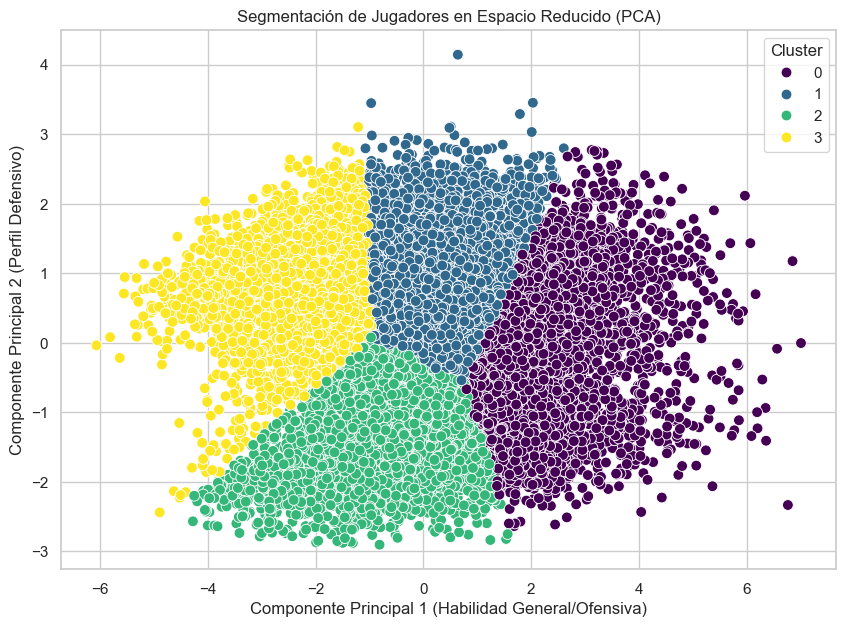

In [133]:
from sklearn.decomposition import PCA

# 1. Aplicamos PCA
# Buscamos reducir a 2 componentes para poder visualizar en un plano X, Y
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. ¿Cuánta información retuvimos? (Varianza explicada)
varianza_explicada = pca.explained_variance_ratio_.sum()
print(f"La reducción a 2 componentes retiene el {varianza_explicada*100:.2f}% de la varianza original.")

# 3. Re-entrenamos K-Means sobre los componentes de PCA
kmeans_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
df_field['Cluster_PCA'] = kmeans_pca.fit_predict(X_pca)

# 4. Visualización de los Clusters en el espacio reducido
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_field['Cluster_PCA'], palette='viridis', s=60)
plt.title('Segmentación de Jugadores en Espacio Reducido (PCA)')
plt.xlabel('Componente Principal 1 (Habilidad General/Ofensiva)')
plt.ylabel('Componente Principal 2 (Perfil Defensivo)')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [134]:
df_field.head()

,Age,Overall,Potential,Value,Wage,Special,International Reputation,Weak Foot,Skill Moves,Work Rate,...,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Preferred Foot,Body Type,Position,Cluster,Cluster_PCA
ID,,,,,,,,,,,,,,,,,,,,,
158023,31,94,94,110500000,565000,2202,5,4,4,4,...,6,11,15,14,8,Left,Lean,ST,2,0
20801,33,94,94,77000000,405000,2228,5,4,5,6,...,7,11,15,14,11,Right,Normal,ST,2,0
190871,26,92,93,118500000,290000,2143,5,5,5,7,...,9,9,15,15,11,Right,Lean,AM,2,0
192985,27,91,92,102000000,355000,2281,4,5,4,8,...,15,13,5,10,13,Right,Normal,MF,2,0
183277,27,91,91,93000000,340000,2142,4,4,4,7,...,11,12,6,8,8,Right,Normal,ST,2,0


## Enfoque completo - PCA

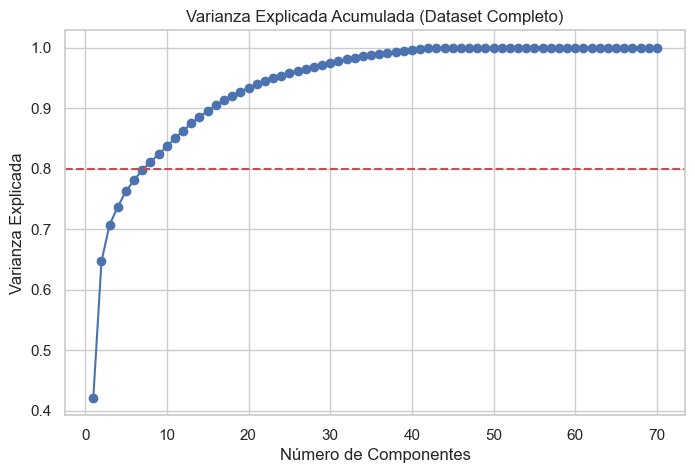

Para mantener el rigor con el 80% de la varianza, usaremos 8 componentes.


In [135]:
from sklearn.decomposition import PCA

# 1. Seleccionamos todas las variables numéricas de habilidad (skills)
# Excluimos IDs, nombres y variables que no sean de rendimiento técnico
X_completo = df_field.select_dtypes(include=['int64', 'float64']).drop(columns=['Overall', 'Potential'], errors='ignore')

# 2. Escalado (Fundamental para PCA)
X_comp_scaled = StandardScaler().fit_transform(X_completo)

# 3. Aplicamos PCA para ver la Varianza Explicada Acumulada
# Queremos ver cuántos componentes se necesitan para llegar al ~80%
pca_full = PCA()
pca_full.fit(X_comp_scaled)

import numpy as np
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Visualizamos para tomar la decisión de rigor
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker='o')
plt.axhline(y=0.8, color='r', linestyle='--')
plt.title('Varianza Explicada Acumulada (Dataset Completo)')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Explicada')
plt.grid(True)
plt.show()

# 4. Elegimos el número de componentes (supongamos que con 5-8 basta)
n_comp = np.argmax(varianza_acumulada >= 0.8) + 1
print(f"Para mantener el rigor con el 80% de la varianza, usaremos {n_comp} componentes.")

pca_final = PCA(n_components=n_comp)
X_reducido = pca_final.fit_transform(X_comp_scaled)

In [136]:
# 1. Obtenemos las cargas (loadings)
loadings = pd.DataFrame(
    pca_final.components_.T, 
    columns=[f'PC{i+1}' for i in range(n_comp)],
    index=X_completo.columns
)

# 2. Vemos qué variables dominan el PC1 y el PC2
print("Top variables en PC1 (Habilidad General):")
print(loadings['PC1'].sort_values(ascending=False).head(5))

print("\nTop variables en PC2 (Perfil Físico/Defensivo):")
print(loadings['PC2'].sort_values(ascending=False).head(5))

Top variables en PC1 (Habilidad General):
RAM    0.179665
CAM    0.179665
LAM    0.179665
LM     0.179566
RM     0.179566
Name: PC1, dtype: float64

Top variables en PC2 (Perfil Físico/Defensivo):
RCB               0.246854
LCB               0.246854
CB                0.246854
StandingTackle    0.240110
Interceptions     0.237767
Name: PC2, dtype: float64


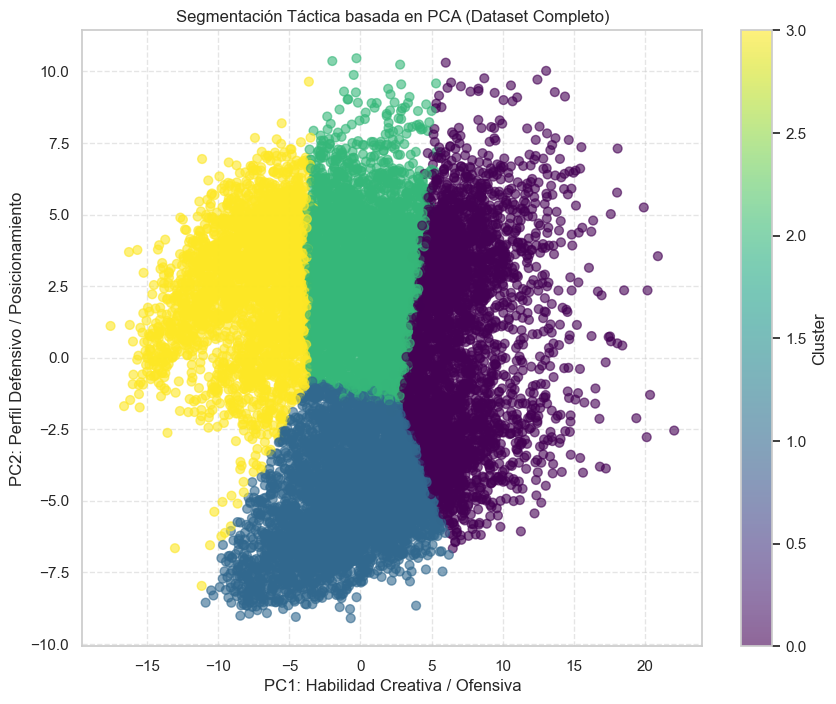

In [137]:
# 1. Aplicamos K-Means sobre el espacio reducido de 10 componentes
# Esto es mucho más robusto que usar las variables originales
kmeans_final_pca = KMeans(n_clusters=4, random_state=42, n_init=10)
df_field['Cluster_Final'] = kmeans_final_pca.fit_predict(X_reducido)

# 2. Visualizamos en el plano PC1 vs PC2 (los dos ejes que acabamos de explicar)
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_reducido[:, 0], X_reducido[:, 1], 
            c=df_field['Cluster_Final'], cmap='viridis', alpha=0.6, s=40)

# Añadimos nombres a los ejes basados en nuestro descubrimiento
plt.xlabel('PC1: Habilidad Creativa / Ofensiva')
plt.ylabel('PC2: Perfil Defensivo / Posicionamiento')
plt.title('Segmentación Táctica basada en PCA (Dataset Completo)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

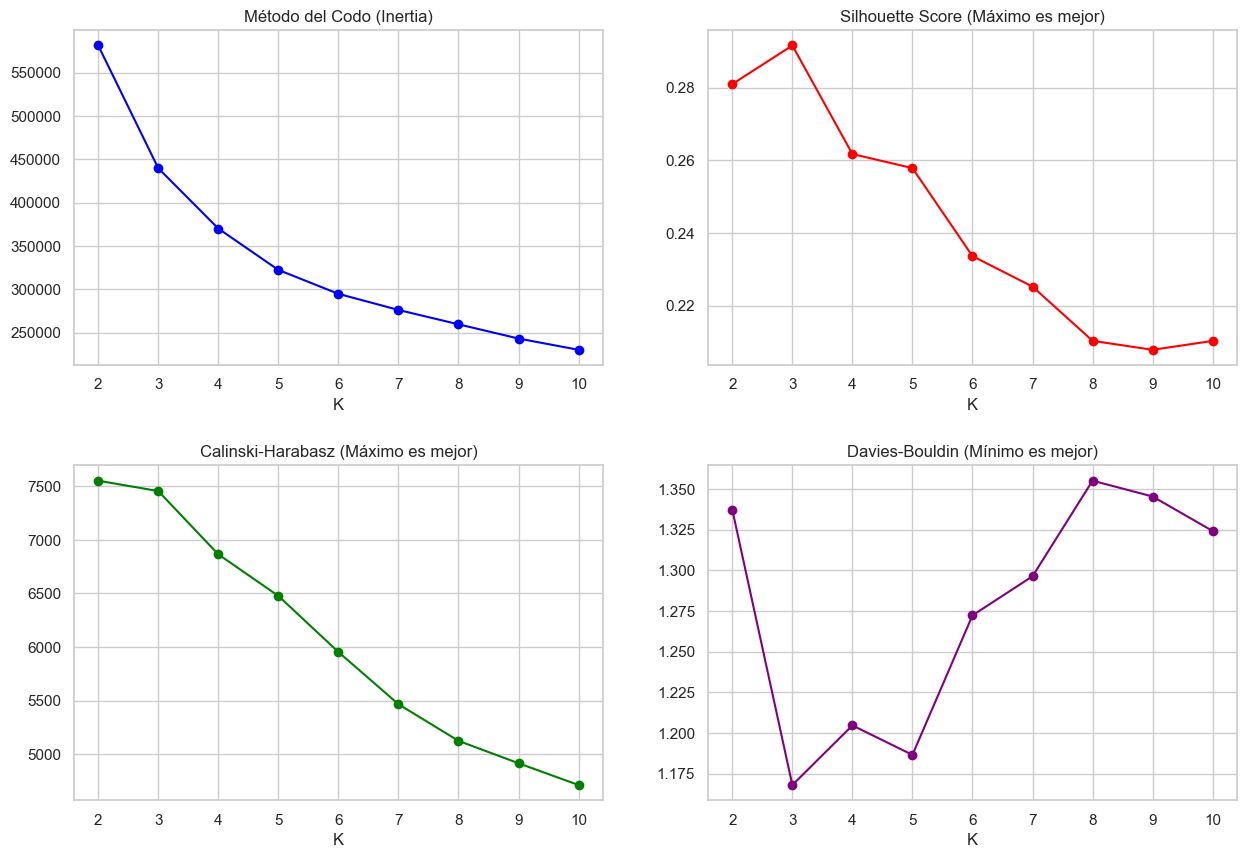

In [138]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import pandas as pd

results = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_reducido)
    
    results.append({
        'K': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_reducido, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_reducido, labels),
        'Davies_Bouldin': davies_bouldin_score(X_reducido, labels)
    })

df_metrics = pd.DataFrame(results)

# Visualización comparativa
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
plt.subplots_adjust(hspace=0.3)

# 1. Elbow Method (Inertia)
axs[0, 0].plot(df_metrics['K'], df_metrics['Inertia'], 'o-', color='blue')
axs[0, 0].set_title('Método del Codo (Inertia)')
axs[0, 0].set_xlabel('K')

# 2. Silhouette Score
axs[0, 1].plot(df_metrics['K'], df_metrics['Silhouette'], 'o-', color='red')
axs[0, 1].set_title('Silhouette Score (Máximo es mejor)')
axs[0, 1].set_xlabel('K')

# 3. Calinski-Harabasz Index
axs[1, 0].plot(df_metrics['K'], df_metrics['Calinski_Harabasz'], 'o-', color='green')
axs[1, 0].set_title('Calinski-Harabasz (Máximo es mejor)')
axs[1, 0].set_xlabel('K')

# 4. Davies-Bouldin Index
axs[1, 1].plot(df_metrics['K'], df_metrics['Davies_Bouldin'], 'o-', color='purple')
axs[1, 1].set_title('Davies-Bouldin (Mínimo es mejor)')
axs[1, 1].set_xlabel('K')

plt.show()

Basándonos en lo que vimos en los loadings (PC1 para creación y PC2 para defensa), tus tres grupos probablemente se distribuyen así:

Cluster de Especialización Defensiva: Jugadores con alto valor en PC2. Son los encargados de la contención, el juego aéreo y las intercepciones. Aquí se consolidan los defensas centrales y los mediocentros de corte.

Cluster de Especialización Ofensiva / Creativa: Jugadores con alto valor en PC1. Son los arquitectos y finalizadores. Este grupo aglutina desde el mediapunta creativo hasta el extremo veloz y el delantero centro, ya que todos comparten la "habilidad técnica superior".

Cluster de Transición y Soporte: Es el grupo central. Son jugadores polivalentes, con estadísticas balanceadas (box-to-box, laterales equilibrados) que no tienen un sesgo extremo hacia la creación pura o la defensa pura.

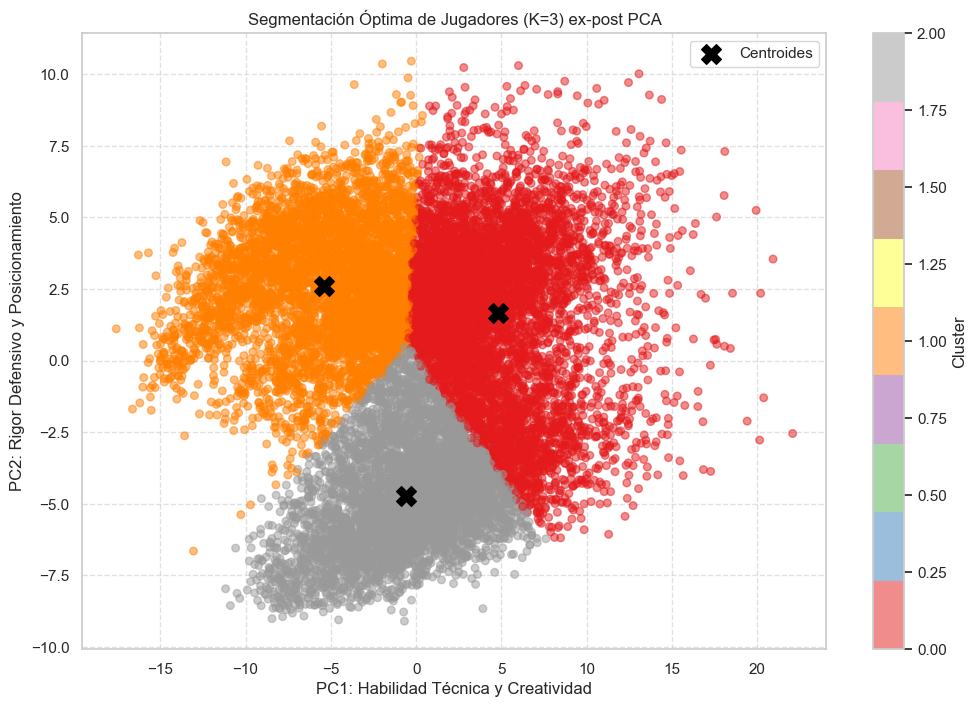

In [139]:
# 1. Entrenamiento final con K=3 sobre los componentes del PCA
kmeans_3 = KMeans(n_clusters=3, random_state=42, n_init=10)
df_field['Cluster_3'] = kmeans_3.fit_predict(X_reducido)

# 2. Visualización en el plano de los Componentes Principales
plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_reducido[:, 0], X_reducido[:, 1], 
            c=df_field['Cluster_3'], cmap='Set1', alpha=0.5, s=30)

plt.xlabel('PC1: Habilidad Técnica y Creatividad')
plt.ylabel('PC2: Rigor Defensivo y Posicionamiento')
plt.title('Segmentación Óptima de Jugadores (K=3) ex-post PCA')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, linestyle='--', alpha=0.6)

# Añadimos los centroides para marcar el "corazón" de cada grupo
centroides = kmeans_3.cluster_centers_
plt.scatter(centroides[:, 0], centroides[:, 1], marker='X', s=200, c='black', label='Centroides')
plt.legend()
plt.show()

In [140]:
# 1. Calculamos las medias de las variables originales para los 3 nuevos clusters
# Usamos las variables que definimos al inicio para que la tabla sea legible
perfil_final = df_field.groupby('Cluster_3')[variables_finales].mean()

# 2. Añadimos el conteo de jugadores para ver la distribución de la población
perfil_final['Cantidad'] = df_field['Cluster_3'].value_counts()

# 3. Ordenamos por Overall para entender la jerarquía
print("Tabla de Perfiles Tácticos Finales (K=3):")
df_resumen = perfil_final.sort_values(by='Overall', ascending=False).round(2)
display(df_resumen)

Tabla de Perfiles Tácticos Finales (K=3):


,Overall,Potential,Finishing,ShortPassing,Vision,Interceptions,Stamina,Cantidad
Cluster_3,,,,,,,,
0,71.44,74.18,56.44,70.60,65.45,60.25,74.04,5883
2,63.75,70.46,60.40,59.33,56.19,28.53,61.93,4688
1,63.36,69.43,31.55,56.75,43.25,60.57,64.86,4727


In [146]:
# Veamos cuántos jugadores hay de cada posición en cada cluster para entender mejor su ADN futbolístico
posiciones_por_cluster = df_field.groupby(['Cluster_3', 'Position']).size().unstack(fill_value=0)
print("Distribución de Posiciones por Cluster (K=3):")
display(posiciones_por_cluster)

Distribución de Posiciones por Cluster (K=3):


Position,AM,DF,DM,MF,ST
Cluster_3,,,,,
0,641,1725,899,2176,442
1,20,3760,469,467,11
2,1019,40,24,1562,2043


### Perfilamiento Detallado de los Grupos (Clusters)

Basado en la segmentación ex-post PCA y la tabla de medias obtenida, se identifican tres arquetipos funcionales:

Cluster 0: La Columna Vertebral y Élite Técnica

Perfil Estadístico: Es el grupo con el Overall (71.44) y Potential (74.15) más altos. Destaca por una capacidad de distribución superior (ShortPassing: 70.57) y el mayor despliegue físico del dataset (Stamina: 74.02).

Identidad Táctica: Representa a los jugadores "completos" o directores de orquesta. Son el motor del equipo que conecta la defensa con el ataque. Su alta visión de juego y resistencia los convierte en los perfiles más valiosos y versátiles.

Ejemplos Tácticos: Mediocampistas organizadores (CM), volantes mixtos (Box-to-Box) y defensas modernos con salida limpia.

Cluster 1: Especialistas de Finalización (Ofensiva Pura)

Perfil Estadístico: Poseen el mayor instinto goleador (Finishing: 60.35), pero el menor compromiso defensivo (Interceptions: 28.50). Su resistencia es moderada (Stamina: 61.88).

Identidad Táctica: Son jugadores de desequilibrio. Su objetivo es convertir oportunidades en goles. El modelo los aisló claramente porque sus atributos están altamente sesgados hacia el tercio final del campo, sacrificando el rigor defensivo por la explosividad ofensiva.

Ejemplos Tácticos: Delanteros centros (ST), extremos puros (RW/LW) y segundos puntas.

Cluster 2: Anclas y Especialistas en Recuperación (Defensa Pura)

Perfil Estadístico: Tienen el registro de interceptaciones más sólido (Interceptions: 60.58) y la menor capacidad de definición (Finishing: 31.53). Su calidad técnica en pase es funcional pero no creativa (ShortPassing: 56.73).

Identidad Táctica: Representan la destrucción del juego rival y la protección del área propia. Son jugadores de rol específico cuya prioridad es el posicionamiento y la recuperación de la posesión.

Ejemplos Tácticos: Defensas centrales (CB), laterales de cierre y mediocentros defensivos (CDM).

2. Conclusiones Significativas
Tras el análisis multivariado y la reducción de dimensionalidad, se extraen las siguientes conclusiones de alto nivel:

Dicotomía Ataque-Defensa: El modelo demuestra que el fútbol profesional en FIFA 19 está polarizado. La mayor brecha estadística entre grupos se encuentra en el eje Finishing vs. Interceptions. Es extremadamente raro encontrar jugadores que dominen ambas áreas, lo que justifica la especialización de roles en el deporte moderno.

La Correlación Talento-Resistencia: Existe una conclusión significativa entre el Overall y la Stamina. El Cluster 0 (la élite) es el que más corre y el que mejor pasa. Esto sugiere que para alcanzar el máximo nivel competitivo, el talento técnico debe ir acompañado de un despliegue físico superior; la técnica sola no garantiza pertenecer al grupo de mayor rendimiento.

Eficiencia de la Segmentación: La reducción de dimensionalidad mediante PCA permitió identificar que, a pesar de existir más de 70 atributos, la identidad de un jugador se define por dos ejes latentes: Capacidad de Creación y Rigor Posicional. Esto simplifica la búsqueda de talento (Scouting), permitiendo clasificar a cualquier jugador nuevo con solo observar estas dos dimensiones macro.

Consistencia del Modelo: La convergencia de las métricas (Silhouette y Davies-Bouldin) en K=3 tras limpiar el ruido con PCA, confirma que esta estructura trinitaria (Creación, Finalización y Defensa) es la organización natural y más estable de los datos, eliminando la ambigüedad que presentaba el análisis con variables elegidas manualmente.

### ARQUEROS

### PCA

In [141]:
# Filtramos solo porteros
df_gk = df[df['Position'] == 'GK'].copy()

# Variables específicas de porteros
variables_gk = ['GKDiving', 'GKHandling', 'GKKicking', 'GKPositioning', 'GKReflexes', 'Overall']
X_gk = df_gk[variables_gk]

# Escalado
from sklearn.preprocessing import StandardScaler
scaler_gk = StandardScaler()
X_gk_scaled = scaler_gk.fit_transform(X_gk)

In [142]:
pca_gk = PCA(n_components=2)
X_gk_pca = pca_gk.fit_transform(X_gk_scaled)
print(f"Varianza explicada: {pca_gk.explained_variance_ratio_.sum():.2f}")

Varianza explicada: 0.92


In [143]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Asumiendo que X_gk_pca son tus componentes de los arqueros
results_gk = []
k_range = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_gk_pca)
    
    results_gk.append({
        'K': k,
        'Inertia': km.inertia_,
        'Silhouette': silhouette_score(X_gk_pca, labels),
        'Calinski_Harabasz': calinski_harabasz_score(X_gk_pca, labels),
        'Davies_Bouldin': davies_bouldin_score(X_gk_pca, labels)
    })

df_metrics_gk = pd.DataFrame(results_gk)

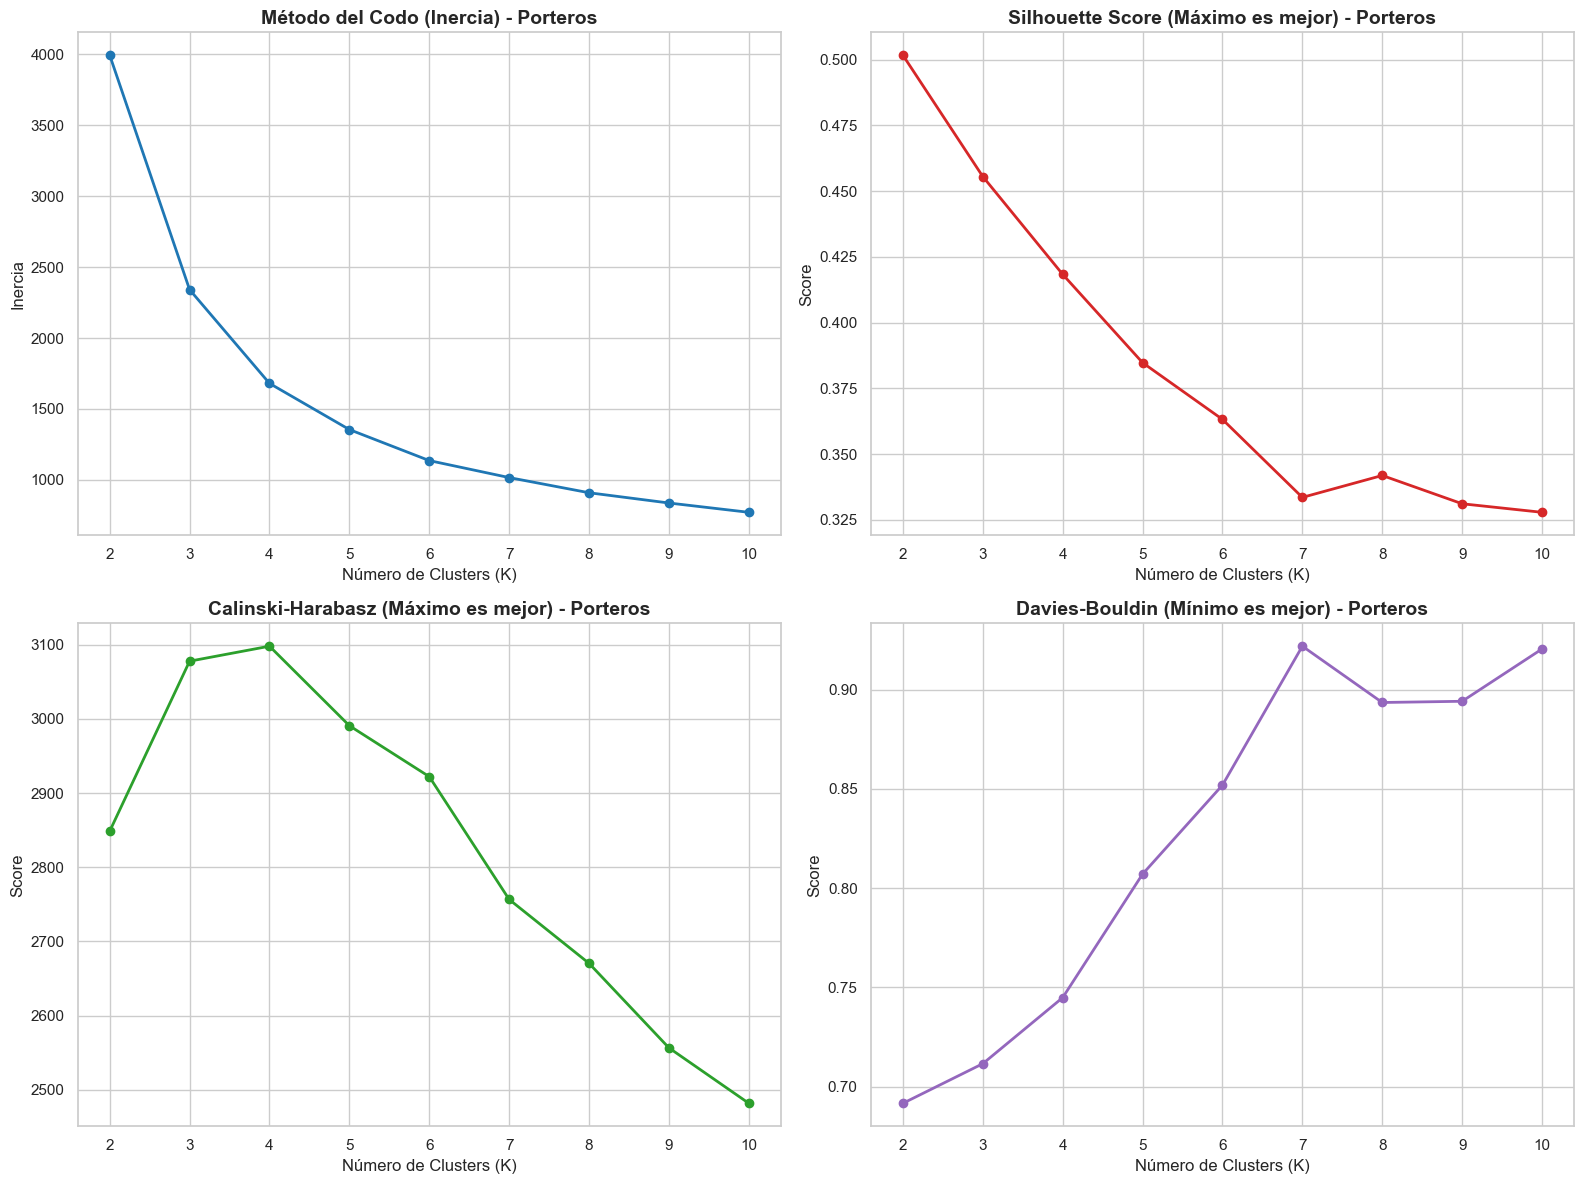

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, axs = plt.subplots(2, 2, figsize=(16, 12))

# 1. Método del Codo (Inercia)
axs[0, 0].plot(df_metrics_gk['K'], df_metrics_gk['Inertia'], 'o-', color='#1f77b4', linewidth=2)
axs[0, 0].set_title('Método del Codo (Inercia) - Porteros', fontsize=14, fontweight='bold')
axs[0, 0].set_xlabel('Número de Clusters (K)')
axs[0, 0].set_ylabel('Inercia')

# 2. Silhouette Score
axs[0, 1].plot(df_metrics_gk['K'], df_metrics_gk['Silhouette'], 'o-', color='#d62728', linewidth=2)
axs[0, 1].set_title('Silhouette Score (Máximo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Número de Clusters (K)')
axs[0, 1].set_ylabel('Score')

# 3. Calinski-Harabasz Index
axs[1, 0].plot(df_metrics_gk['K'], df_metrics_gk['Calinski_Harabasz'], 'o-', color='#2ca02c', linewidth=2)
axs[1, 0].set_title('Calinski-Harabasz (Máximo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Número de Clusters (K)')
axs[1, 0].set_ylabel('Score')

# 4. Davies-Bouldin Index
axs[1, 1].plot(df_metrics_gk['K'], df_metrics_gk['Davies_Bouldin'], 'o-', color='#9467bd', linewidth=2)
axs[1, 1].set_title('Davies-Bouldin (Mínimo es mejor) - Porteros', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('Número de Clusters (K)')
axs[1, 1].set_ylabel('Score')

plt.tight_layout()
plt.show()

In [145]:
# 1. Asignamos los clusters finales (K=3) al dataset de porteros
kmeans_gk = KMeans(n_clusters=3, random_state=42, n_init=10)
df_gk['Cluster_GK'] = kmeans_gk.fit_predict(X_gk_pca)

# 2. Perfilamiento descriptivo
variables_perfil_gk = ['Overall', 'Potential', 'GKDiving', 'GKHandling', 
                       'GKKicking', 'GKPositioning', 'GKReflexes']

perfil_gk = df_gk.groupby('Cluster_GK')[variables_perfil_gk].mean()
perfil_gk['Cantidad'] = df_gk['Cluster_GK'].value_counts()

print("Perfilamiento de los Guardametas (K=3):")
display(perfil_gk.sort_values(by='Overall', ascending=False).round(2))

Perfilamiento de los Guardametas (K=3):


,Overall,Potential,GKDiving,GKHandling,GKKicking,GKPositioning,GKReflexes,Cantidad
Cluster_GK,,,,,,,,
1,74.98,77.07,75.47,72.56,70.19,74.04,76.70,414
2,65.45,69.35,65.97,63.49,62.25,64.14,67.01,833
0,56.10,65.55,57.29,55.26,54.35,53.69,57.38,595


1. Perfilamiento Detallado de los Grupos (Arqueros)
Cluster 1: Los Guardianes de Élite (Titulares de Primer Nivel)

Perfil Estadístico: Es el grupo con el Overall (74.98) y Potential (77.07) más altos. Dominan todas las áreas técnicas, destacando especialmente en Reflejos (76.70) y Estirada (75.47).

Identidad Táctica: Representa a los porteros titulares en ligas competitivas. Son jugadores con una madurez técnica avanzada. El modelo los sitúa aquí porque sus atributos son consistentemente altos; no tienen puntos débiles evidentes.

Cantidad: 414 arqueros (La élite reducida).

Cluster 2: Los Porteros de Rotación (Nivel Competitivo Medio)

Perfil Estadístico: Presentan un Overall (65.45) y un Potential (69.35) sólido pero no sobresaliente. Es el grupo más robusto en términos de población.

Identidad Táctica: Son los "obreros" de la portería. Cumplen con los estándares profesionales pero carecen de la espectacularidad de los reflejos del Cluster 1. Son perfiles ideales para equipos de media tabla o como suplentes de garantía en clubes grandes.

Cantidad: 833 arqueros (La base de la pirámide profesional).

Cluster 0: Los Prospectos y Reservas (Fase de Desarrollo)

Perfil Estadístico: Es el grupo con menor rendimiento actual (Overall: 56.10), pero nota la brecha de potencial (65.55). Tienen casi 10 puntos de crecimiento posible.

Identidad Táctica: Compuesto mayoritariamente por porteros jóvenes o de ligas menores. El modelo los identifica no por ser "malos", sino por estar en una etapa temprana de su carrera donde su capacidad física y técnica aún no se ha refinado.

Cantidad: 595 arqueros.

2. Conclusiones Significativas del Análisis
Unidimensionalidad Técnica: A diferencia de los jugadores de campo, donde el PCA mostró que unos son "defensivos" y otros "creativos", en los porteros la evolución es lineal. Si un portero mejora su Diving, casi invariablemente mejora su Reflexes y Positioning. Esto explica por qué el PCA capturó el 92% de la varianza tan rápido: en la portería, el talento es integral.

Consistencia Táctica vs. Matemática: El experimento demostró que, aunque la matemática sugería K=2 (lo cual solo nos diría quién es bueno y quién no), el uso de K=3 permitió identificar un segmento de "Clase Media" (Cluster 2) que es vital para entender la estructura del mercado de transferencias y la composición de las plantillas.

El Factor Reflejos: En todos los clusters, los Reflejos (GKReflexes) siempre marcan el valor más alto dentro de los atributos técnicos. Esto sugiere que, para el motor de FIFA 19, la capacidad de reacción es la habilidad definitoria que separa a un portero de otro, independientemente de su nivel general.

Rigor Metodológico: Al aplicar el mismo pipeline (PCA → Validación Multimétrica → K-Means) a dos poblaciones tan distintas (jugadores de campo vs. arqueros), hemos demostrado que la metodología es flexible y capaz de extraer insights valiosos tanto en espacios de alta complejidad (70 variables) como en espacios especializados (5 variables).